# Lab 11: Visualizing Time Series Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot, lag_plot

# Load dataset
df = pd.read_csv("Datasets/1_Daily_minimum_temps.csv")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Remove non-numeric values and convert to float
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

df.dropna(subset=['Temp'], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_22504\1527129965.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


1. Line Plot

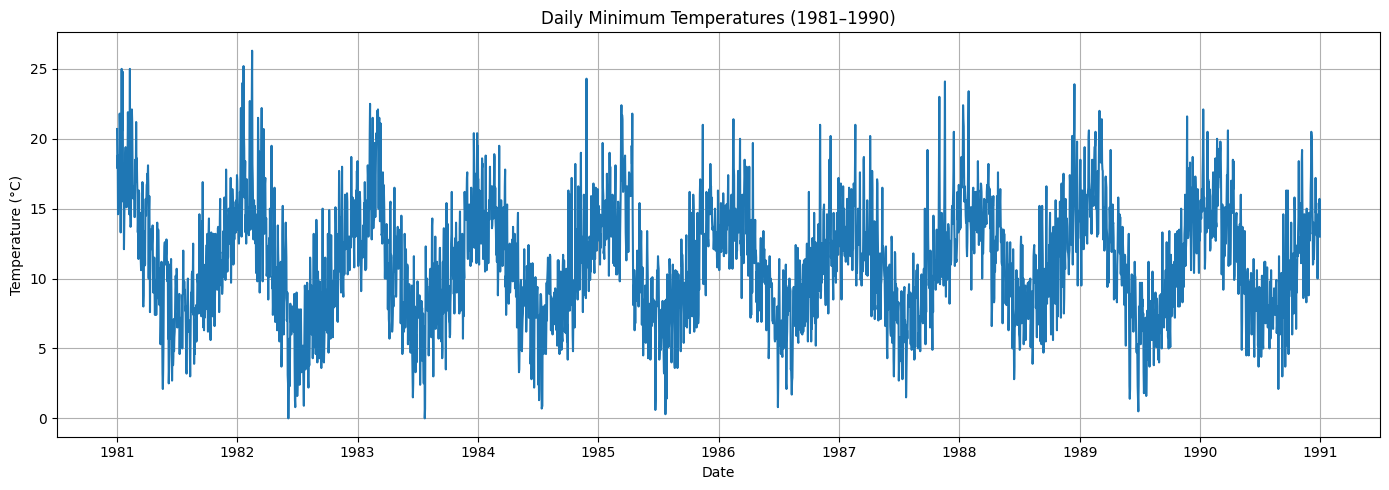

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Temp'], label='Temperature')
plt.title('Daily Minimum Temperatures (1981–1990)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()


2. Seasonal Decomposition

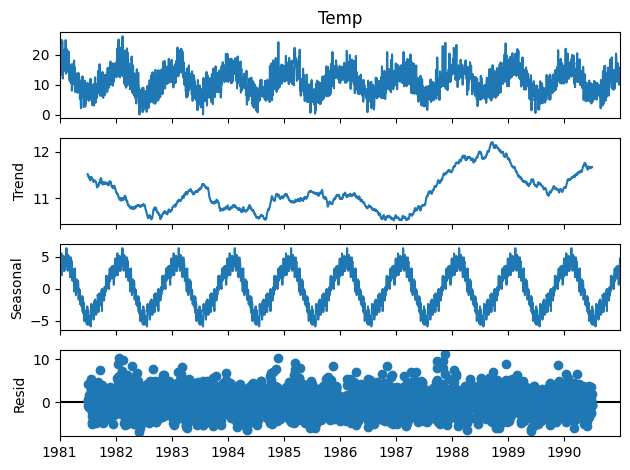

In [10]:
result = seasonal_decompose(df['Temp'], model='additive', period=365)
result.plot()
plt.tight_layout()
plt.show()

3. Barchart

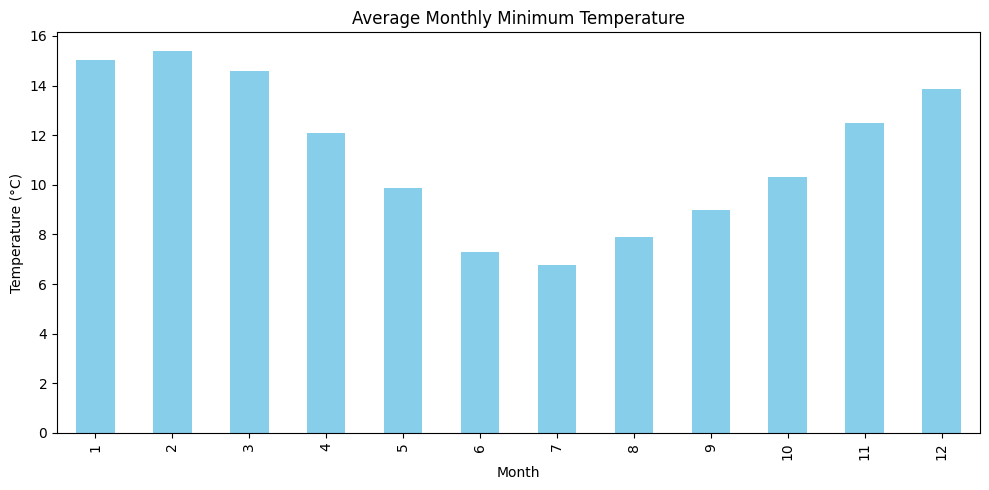

In [11]:
df['Month'] = df.index.month
monthly_avg = df.groupby('Month')['Temp'].mean()
plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='skyblue')
plt.title('Average Monthly Minimum Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

4. Calendar Heatmap


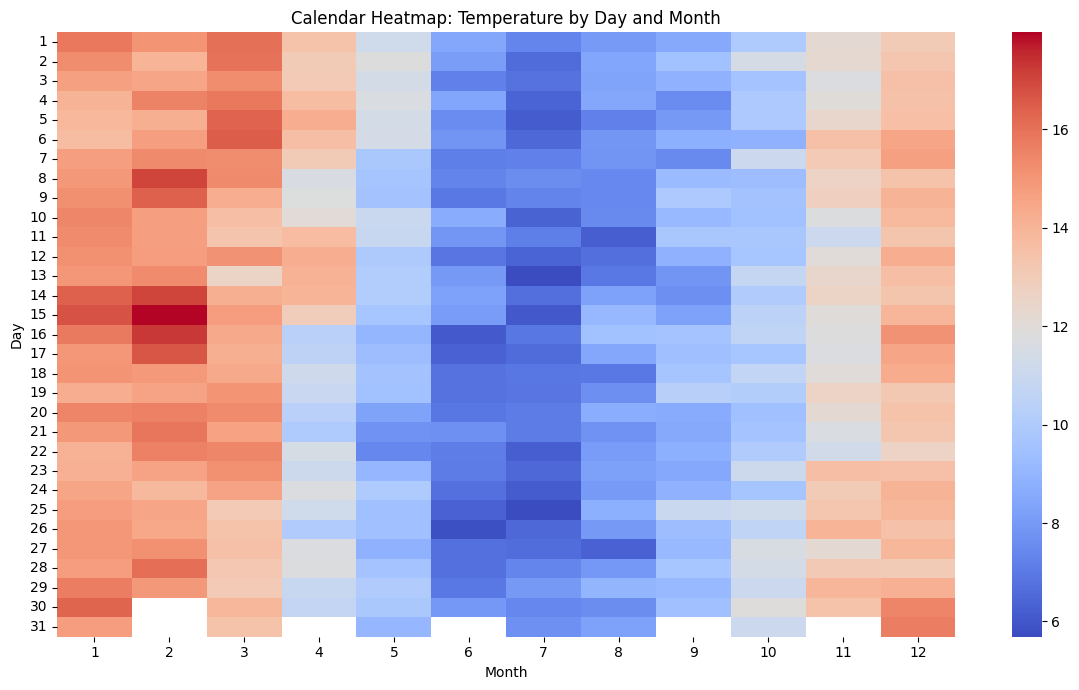

In [12]:
df['Day'] = df.index.day
pivot = df.pivot_table(index='Day', columns='Month', values='Temp', aggfunc='mean')
plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap='coolwarm', annot=False)
plt.title('Calendar Heatmap: Temperature by Day and Month')
plt.xlabel('Month')
plt.ylabel('Day')
plt.tight_layout()
plt.show()

5. Autocorrection Plot

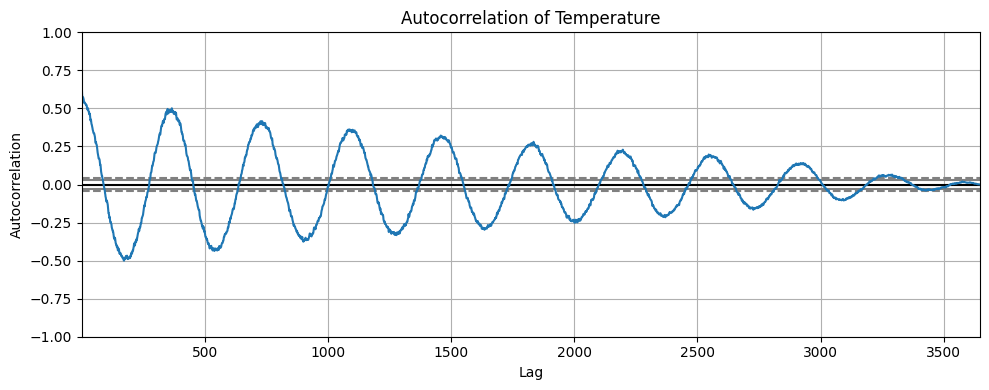

In [13]:
plt.figure(figsize=(10, 4))
autocorrelation_plot(df['Temp'])
plt.title('Autocorrelation of Temperature')
plt.tight_layout()
plt.show()

6. Lag Plot

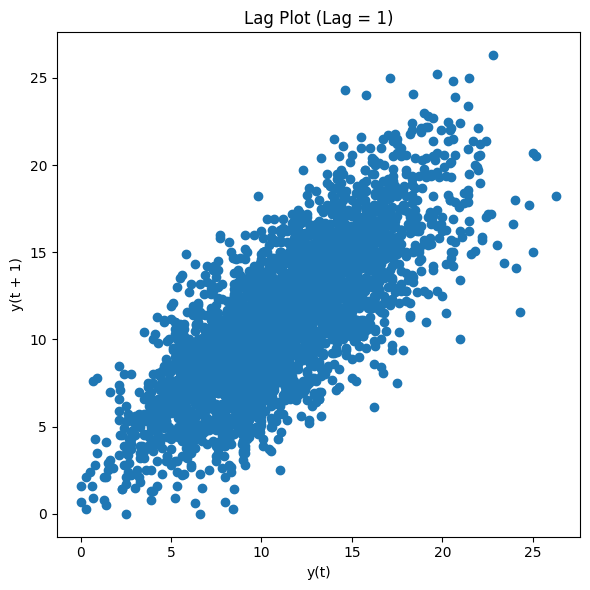

In [14]:
plt.figure(figsize=(6, 6))
lag_plot(df['Temp'], lag=1)
plt.title('Lag Plot (Lag = 1)')
plt.tight_layout()
plt.show()